# IDRA Data Science & AI Capstone Project
## The Impact of Socio-Economic Factors on Academic Performance: A Comprehensive Analysis of Student Outcomes

**Dataset:** `P_2_StudentPerformanceFactors.csv`  
**Task:** Regression — predict `Exam_Score`

This notebook follows the IDRA capstone workflow: dataset understanding, data cleaning, preprocessing, EDA, statistical analysis, visualization, machine learning, evaluation, discussion, and conclusions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)


## 1. Load the Dataset

In [2]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

df.head()


Saving P_2_StudentPerformanceFactors.csv to P_2_StudentPerformanceFactors.csv


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)


Shape: (6607, 20)

Data types:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


## 2. Data Quality Inspection

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values:")
print(missing[missing > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)


Missing values:
Parental_Education_Level    90
Teacher_Quality             78
Distance_from_Home          67
dtype: int64

Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


### Cleaning decision
The target `Exam_Score` contains one value above the logical 0–100 score range. That record is excluded because it is an invalid target value, not a plausible feature outlier.

The remaining missing values are in categorical features (`Teacher_Quality`, `Parental_Education_Level`, and `Distance_from_Home`). They are retained and handled during preprocessing using the most-frequent category so that useful observations are not unnecessarily discarded.


In [5]:
invalid = ~df["Exam_Score"].between(0, 100)
print("Invalid target records:", invalid.sum())
display(df.loc[invalid])

clean = df.loc[~invalid].copy()

for c in clean.select_dtypes(include="object").columns:
    clean[c] = clean[c].str.strip()

print("Cleaned shape:", clean.shape)
print("Remaining duplicates:", clean.duplicated().sum())


Invalid target records: 1


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


Cleaned shape: (6606, 20)
Remaining duplicates: 0


## 3. Exploratory Data Analysis

In [6]:
clean.describe().T


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6606.0,19.974266,5.990424,1.0,16.0,20.0,24.0,44.0
Attendance,6606.0,79.974720,11.546219,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6606.0,7.029216,1.468177,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6606.0,75.067817,14.399184,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6606.0,1.493188,1.229907,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6606.0,2.967605,1.031309,0.0,2.0,3.0,4.0,6.0
Exam_Score,6606.0,67.230548,3.868502,55.0,65.0,67.0,69.0,100.0


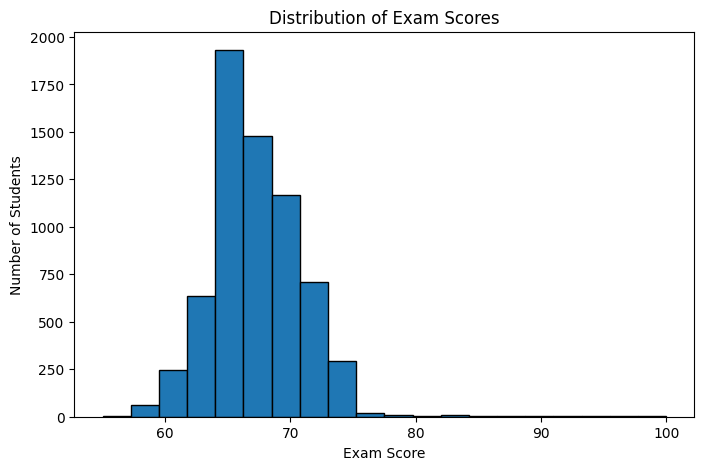

In [7]:
plt.figure(figsize=(8,5))
plt.hist(clean["Exam_Score"], bins=20, edgecolor="black")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")
plt.show()


In [8]:
numeric_cols = clean.select_dtypes(include=np.number).columns
corr = clean[numeric_cols].corr()["Exam_Score"].sort_values(ascending=False)
print(corr)


Exam_Score           1.000000
Attendance           0.582458
Hours_Studied        0.446514
Previous_Scores      0.174461
Tutoring_Sessions    0.153754
Physical_Activity    0.027943
Sleep_Hours         -0.016194
Name: Exam_Score, dtype: float64


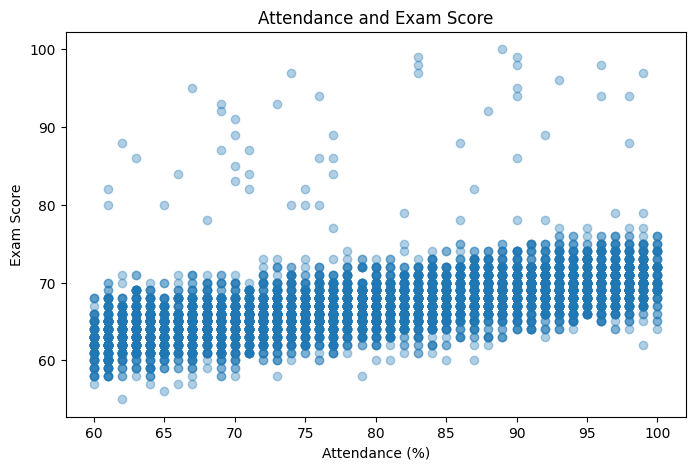

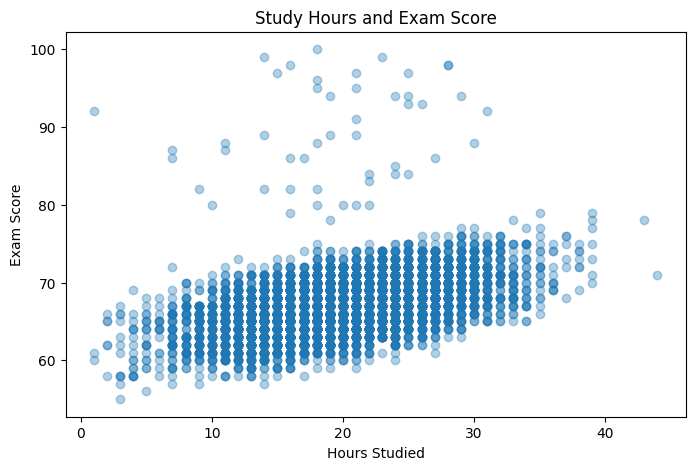

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(clean["Attendance"], clean["Exam_Score"], alpha=0.35)
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.title("Attendance and Exam Score")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(clean["Hours_Studied"], clean["Exam_Score"], alpha=0.35)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Study Hours and Exam Score")
plt.show()


### Group comparisons

In [10]:
for col in [
    "Parental_Involvement", "Access_to_Resources", "Motivation_Level",
    "Family_Income", "Teacher_Quality", "Parental_Education_Level",
    "Peer_Influence", "Distance_from_Home", "School_Type"
]:
    print("\n", col)
    display(clean.groupby(col, dropna=False)["Exam_Score"].agg(["count","mean"]).round(2))



 Parental_Involvement


,count,mean
Parental_Involvement,,
High,1908,68.09
Low,1336,66.33
Medium,3362,67.10



 Access_to_Resources


,count,mean
Access_to_Resources,,
High,1975,68.09
Low,1313,66.20
Medium,3318,67.12



 Motivation_Level


...

,count,mean
Peer_Influence,,
Negative,1377,66.56
Neutral,2592,67.20
Positive,2637,67.61



 Distance_from_Home


,count,mean
Distance_from_Home,,
Far,658,66.46
Moderate,1997,66.96
Near,3884,67.51
NaN,67,66.43



 School_Type


,count,mean
School_Type,,
Private,2009,67.29
Public,4597,67.21


## 4. Statistical Analysis

In [11]:
print("Exam score mean:", clean["Exam_Score"].mean())
print("Exam score median:", clean["Exam_Score"].median())
print("Exam score standard deviation:", clean["Exam_Score"].std())
print("Exam score minimum:", clean["Exam_Score"].min())
print("Exam score maximum:", clean["Exam_Score"].max())


Exam score mean: 67.23054798667877
Exam score median: 67.0
Exam score standard deviation: 3.868502350258686
Exam score minimum: 55
Exam score maximum: 100


The strongest numerical association with `Exam_Score` in this dataset is `Attendance`, followed by `Hours_Studied`. Correlation indicates association, not causation.


## 5. Machine Learning Preparation

In [12]:
X = clean.drop(columns="Exam_Score")
y = clean["Exam_Score"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 5284
Testing rows: 1322


## 6. Train and Compare Regression Models

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1, min_samples_leaf=2
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42, n_estimators=150, max_depth=3, learning_rate=0.05
    )
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, train_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Train RMSE": mean_squared_error(y_train, train_pred) ** 0.5,
        "Test RMSE": mean_squared_error(y_test, test_pred) ** 0.5,
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred)
    })

results_df = pd.DataFrame(results).sort_values("Test RMSE")
results_df


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,0.503035,0.415976,2.109233,1.521263,0.710979,0.825000
2,Gradient Boosting,0.875959,0.849926,2.104831,1.763784,0.712184,0.764755
1,Random Forest,0.541548,1.027809,1.378709,1.912414,0.876512,0.723437


## 7. Final Model Evaluation

In [14]:
best_name = results_df.iloc[0]["Model"]
print("Selected model:", best_name)

best_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", models[best_name])
])
best_model.fit(X_train, y_train)

test_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, test_pred))
print("RMSE:", mean_squared_error(y_test, test_pred) ** 0.5)
print("R2:", r2_score(y_test, test_pred))


Selected model: Linear Regression
MAE: 0.4159761177572445
RMSE: 1.521262510926088
R2: 0.8249999018449949


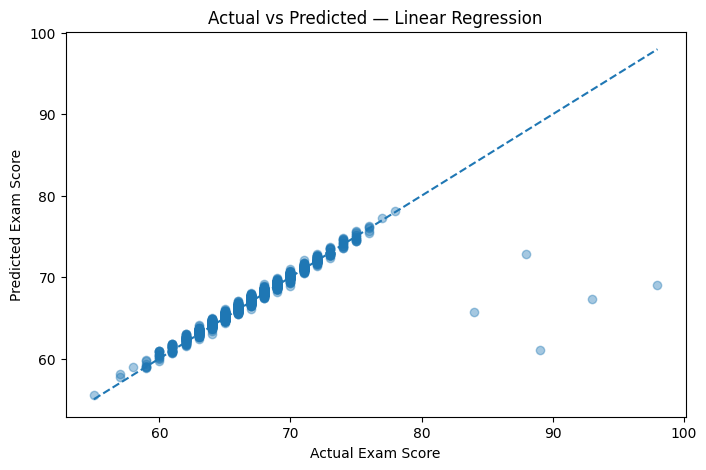

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, test_pred, alpha=0.4)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title(f"Actual vs Predicted — {best_name}")
plt.show()


## 8. Findings and Discussion

1. Attendance has the strongest numerical correlation with exam score in the dataset.
2. Study hours also show a positive association with exam performance.
3. Higher parental involvement and access to resources are associated with higher average exam scores in the group comparisons.
4. Positive peer influence is associated with a higher average score than negative peer influence.
5. Linear Regression gives the strongest test performance among the three evaluated models in this run.
6. Model quality should be interpreted as predictive performance on this dataset, not as evidence that any variable causes higher scores.

## 9. Limitations

- The dataset represents observed associations and does not establish causality.
- Some categorical fields contain missing values.
- The dataset may not represent all student populations or educational settings.
- The model performance may change on a different population or future data.
- The analysis does not include every possible factor affecting academic performance.

## 10. Conclusion

The analysis indicates that attendance and study effort are important predictive factors for exam performance in this dataset, while several socioeconomic and learning-environment variables also show meaningful group differences. The final regression model provides a reproducible baseline for predicting exam scores and can support further investigation of student outcomes.


## 11. Export Cleaned Dataset

The cleaned dataset can be saved with:

```python
clean.to_csv("P_2_StudentPerformanceFactors_Cleaned.csv", index=False)
```
